# 🗑️ Klasifikasi Sampah B3 vs Non-B3
**Transfer Learning dengan MobileNetV3Large — Google Colab Edition**

Dataset: Classification Sampah B3 (Roboflow)
- Train : ~14.771 gambar (B3: 3.960 | non-B3: 10.811)
- Valid : ~1.413 gambar (B3: 376 | non-B3: 1.037)
- Test  : ~707 gambar (B3: 195 | non-B3: 512)

### 🆕 Perubahan dari MobileNetV2 ke MobileNetV3Large
| Aspek | MobileNetV2 | MobileNetV3Large |
|---|---|---|
| Backbone | Inverted Residuals | Hard-Swish + SE Blocks |
| Akurasi ImageNet (Top-1) | 71.8% | 75.2% |
| Efisiensi | Baik | Lebih baik (NAS-optimized) |
| Preprocessing | `mobilenet_v2.preprocess_input` | `mobilenet_v3.preprocess_input` |
| Input size default | 224×224 | 224×224 |
| Head bawaan | GlobalAvgPool2D | Sudah ada Avg + FC di base |

> ⚠️ **Pastikan Runtime → Change runtime type → T4 GPU sudah aktif sebelum menjalankan notebook ini!**

## 0. ✅ Cek GPU & Mount Google Drive

In [2]:
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
print(f"TensorFlow : {tf.__version__}")
print(f"GPU        : {gpus}")
if not gpus:
    print("⚠️  GPU tidak terdeteksi! Pergi ke Runtime → Change runtime type → T4 GPU")
else:
    # Aktifkan memory growth agar VRAM tidak langsung di-alokasikan penuh
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print("✅ GPU siap digunakan!")

TensorFlow : 2.21.0
GPU        : []
⚠️  GPU tidak terdeteksi! Pergi ke Runtime → Change runtime type → T4 GPU


In [3]:
# Local environment setup - tidak perlu mount Google Drive
print("✅ Environment setup selesai")

✅ Environment setup selesai


## 1. 📦 Ekstrak Dataset dari ZIP

In [4]:
import zipfile
import os
from pathlib import Path

ZIP_PATH    = Path("./dataset/dataset.zip")
EXTRACT_DIR = Path("./dataset")

if not ZIP_PATH.exists():
    print(f"❌ {ZIP_PATH} tidak ditemukan!")
    print("   Download dataset dari Roboflow dan letakkan di folder project/dataset/")
else:
    if not (EXTRACT_DIR / "train").exists():
        print(f"Mengekstrak {ZIP_PATH} ...")
        with zipfile.ZipFile(ZIP_PATH, 'r') as zf:
            zf.extractall(EXTRACT_DIR)
        print(f"✅ Ekstraksi selesai → {EXTRACT_DIR}")
    else:
        print(f"✅ Dataset sudah ada di {EXTRACT_DIR}, skip ekstraksi.")

    print("\nStruktur dataset:")
    for split in ["train", "valid", "test"]:
        for cls in ["B3", "non-B3"]:
            folder = EXTRACT_DIR / split / cls
            if folder.exists():
                n = len(list(folder.glob("*.jpg")) + list(folder.glob("*.png")))
                print(f"   {split:5s}/{cls:6s} → {n:5d} gambar")
            else:
                print(f"   ⚠️  {split}/{cls} tidak ditemukan!")

Mengekstrak dataset\dataset.zip ...
✅ Ekstraksi selesai → dataset

Struktur dataset:
   train/B3     → 11261 gambar
   train/non-B3 → 20582 gambar
   valid/B3     →  1062 gambar
   valid/non-B3 →  1954 gambar
   test /B3     →   541 gambar
   test /non-B3 →   935 gambar


## 2. 📚 Import Library

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow import keras
from tensorflow.keras import layers

# ✅ UPGRADE: MobileNetV3Large menggantikan MobileNetV2
from tensorflow.keras.applications import MobileNetV3Large
from tensorflow.keras.applications.mobilenet_v3 import preprocess_input as mobilenetv3_preprocess

from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
)

from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, precision_score, recall_score, f1_score
)
from sklearn.utils.class_weight import compute_class_weight

print("✅ Semua library berhasil di-import")
print(f"   Backbone : MobileNetV3Large")

✅ Semua library berhasil di-import
   Backbone : MobileNetV3Large


## 3. ⚙️ Konfigurasi Path & Hyperparameter

In [6]:
DATASET_DIR = Path(EXTRACT_DIR)
TRAIN_DIR   = DATASET_DIR / "train"
VALID_DIR   = DATASET_DIR / "valid"
TEST_DIR    = DATASET_DIR / "test"

PROJECT_DIR = Path("./")
MODEL_PATH  = PROJECT_DIR / "model_b3_v3.h5"
CKPT_PATH   = PROJECT_DIR / "checkpoint_best_v3.h5"

# ✅ MobileNetV3Large optimal pada 224×224
IMG_SIZE   = (224, 224)
BATCH_SIZE = 32
EPOCHS_FT  = 10    # Fase 1: head training (base frozen)
EPOCHS_UN  = 20    # Fase 2: fine-tuning (partial unfreeze)
SEED       = 42

print(f"Train : {TRAIN_DIR}  | exists: {TRAIN_DIR.exists()}")
print(f"Valid : {VALID_DIR}  | exists: {VALID_DIR.exists()}")
print(f"Test  : {TEST_DIR}   | exists: {TEST_DIR.exists()}")
print(f"Model akan disimpan ke: {MODEL_PATH}")

Train : dataset\train  | exists: True
Valid : dataset\valid  | exists: True
Test  : dataset\test   | exists: True
Model akan disimpan ke: model_b3_v3.h5


## 4. 📂 Load Dataset

In [7]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED,
    label_mode="binary",
    interpolation="bilinear",
)

valid_ds = tf.keras.utils.image_dataset_from_directory(
    VALID_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
    label_mode="binary",
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
    label_mode="binary",
)

CLASS_NAMES = train_ds.class_names
print(f"Kelas terdeteksi : {CLASS_NAMES}")
print(f"Batch train      : {len(train_ds)}")
print(f"Batch valid      : {len(valid_ds)}")
print(f"Batch test       : {len(test_ds)}")

Found 31843 files belonging to 2 classes.
Found 3016 files belonging to 2 classes.
Found 1476 files belonging to 2 classes.
Kelas terdeteksi : ['B3', 'non-B3']
Batch train      : 996
Batch valid      : 95
Batch test       : 47


## 5. ⚖️ Hitung Class Weight (Penanganan Imbalance)

In [8]:
all_labels = np.concatenate([y.numpy() for _, y in train_ds]).flatten().astype(int)

class_weights_arr = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(all_labels),
    y=all_labels
)
class_weight_dict = dict(enumerate(class_weights_arr))

print("Class weight:")
for idx, name in enumerate(CLASS_NAMES):
    print(f"  [{idx}] {name:8s} → weight = {class_weight_dict[idx]:.4f}")

Class weight:
  [0] B3       → weight = 1.4139
  [1] non-B3   → weight = 0.7736


## 6. 🔄 Preprocessing & Augmentasi

> ⚠️ **Penting:** MobileNetV3 menggunakan `mobilenet_v3.preprocess_input` (bukan `mobilenet_v2`). Fungsi ini melakukan normalisasi ke rentang `[-1, 1]` yang sedikit berbeda dari V2.

In [9]:
# ✅ Augmentasi ditingkatkan: tambah RandomTranslation & RandomSharpness
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
    layers.RandomTranslation(0.10, 0.10),   # ✅ Baru
    layers.RandomBrightness(0.10),
    layers.RandomContrast(0.10),
], name="data_augmentation")

# ✅ UPGRADE: ganti ke mobilenet_v3 preprocess_input
def preprocess_train(images, labels):
    images = data_augmentation(images, training=True)
    images = mobilenetv3_preprocess(images)
    return images, labels

def preprocess_eval(images, labels):
    images = mobilenetv3_preprocess(images)
    return images, labels

AUTOTUNE = tf.data.AUTOTUNE

train_ds_proc = train_ds.map(preprocess_train, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
valid_ds_proc = valid_ds.map(preprocess_eval,  num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
test_ds_proc  = test_ds.map(preprocess_eval,   num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)

print("✅ Pipeline preprocessing & augmentasi siap")
print("   Preprocessing : mobilenet_v3.preprocess_input")

✅ Pipeline preprocessing & augmentasi siap
   Preprocessing : mobilenet_v3.preprocess_input


## 7. 🖼️ Visualisasi Sampel Dataset

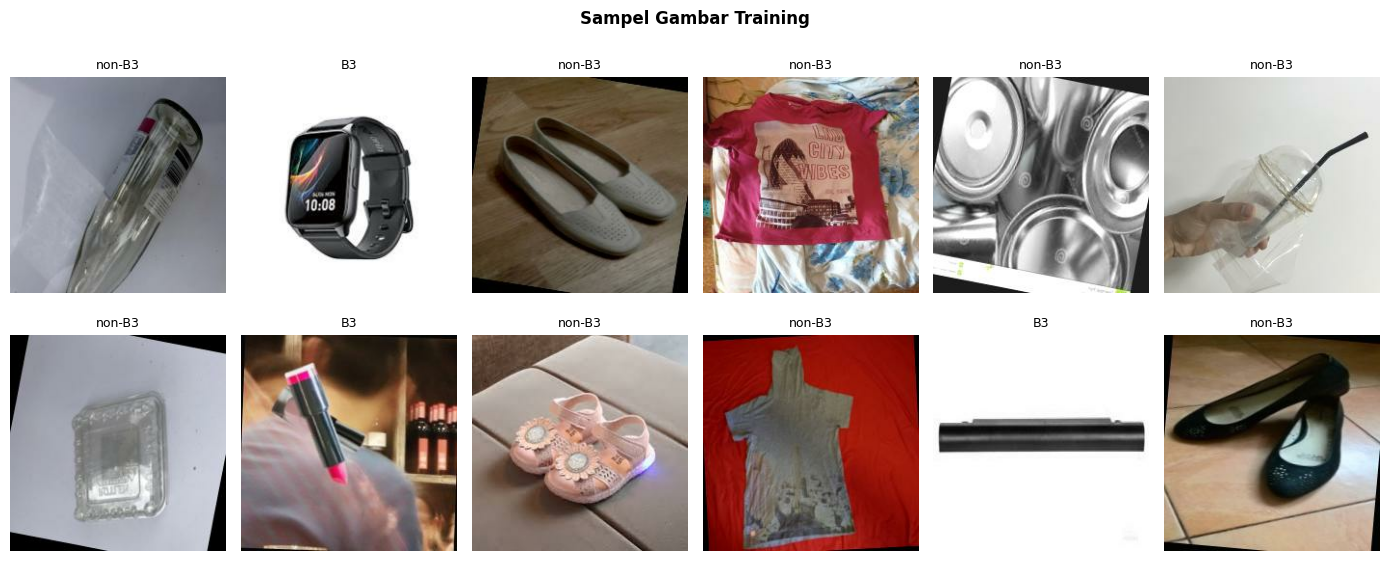

In [10]:
plt.figure(figsize=(14, 6))
for images, labels in train_ds.take(1):
    for i in range(min(12, len(images))):
        ax = plt.subplot(2, 6, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(CLASS_NAMES[int(labels[i].numpy().item())], fontsize=9)
        plt.axis("off")
plt.suptitle("Sampel Gambar Training", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

## 8. 🏗️ Bangun Model (MobileNetV3Large Transfer Learning)

### Arsitektur MobileNetV3Large
- **Hard-Swish activation** — lebih efisien dari ReLU6 (V2)
- **Squeeze-and-Excitation (SE) blocks** — attention mekanisme pada channel
- **NAS-optimized** — arsitektur ditemukan lewat Neural Architecture Search
- **`include_preprocessing=False`** — kita handle sendiri agar augmentasi konsisten

### Strategi Head
```
MobileNetV3Large (frozen)
  └─ GlobalAveragePooling2D
      └─ BatchNormalization
          └─ Dense(256, relu) + Dropout(0.4)
              └─ Dense(128, relu) + Dropout(0.3)
                  └─ Dense(1, sigmoid)  ← output B3 / non-B3
```

In [11]:
def build_model(trainable_base=False):
    """
    Membangun model klasifikasi binary dengan MobileNetV3Large sebagai backbone.

    include_preprocessing=False → kita pakai preprocess_input manual
    agar augmentasi dan preprocessing konsisten di semua fase.
    """
    # ✅ UPGRADE: MobileNetV3Large
    base_model = MobileNetV3Large(
        input_shape=(*IMG_SIZE, 3),
        include_top=False,
        weights="imagenet",
        include_preprocessing=False,  # ✅ kita handle preprocessing sendiri
    )
    base_model.trainable = trainable_base

    inputs = keras.Input(shape=(*IMG_SIZE, 3), name="input_image")
    x = base_model(inputs, training=trainable_base)

    # Head klasifikasi
    x = layers.GlobalAveragePooling2D(name="gap")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(256, activation="relu", name="dense_256",
                     kernel_regularizer=keras.regularizers.l2(1e-4))(x)  # ✅ L2 regularisasi
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(128, activation="relu", name="dense_128",
                     kernel_regularizer=keras.regularizers.l2(1e-4))(x)  # ✅ L2 regularisasi
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(1, activation="sigmoid", name="output")(x)

    model = keras.Model(inputs, outputs, name="b3_classifier_v3")
    return model, base_model


model, base_model = build_model(trainable_base=False)
model.summary()

total_params     = model.count_params()
trainable_params = sum(tf.size(w).numpy() for w in model.trainable_variables)
print(f"\nTotal parameter    : {total_params:,}")
print(f"Trainable (fase 1) : {trainable_params:,}")

12683000/12683000 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "b3_classifier_v3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV3Large (Functional)   │ (None, 7, 7, 960)      │     2,996,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 960)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 960)            │         3,840 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_256 (Dense)               │ (None, 256)            │       246,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_128 (Dense)               │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,279,233 (12.51 MB)

 Trainable params: 280,961 (1.07 MB)

 Non-trainable params: 2,998,272 (11.44 MB)


Total parameter    : 3,279,233
Trainable (fase 1) : 280,961


## 9. 🔥 Fase 1 — Training Head (Base Frozen)

In [12]:
# ✅ Tambah F1Score metric (butuh TF >= 2.13 atau keras >= 2.13)
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        keras.metrics.Precision(name="precision"),
        keras.metrics.Recall(name="recall"),
        keras.metrics.AUC(name="auc"),
    ]
)

callbacks_phase1 = [
    EarlyStopping(monitor="val_auc", patience=4, mode="max",
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2,
                     min_lr=1e-6, verbose=1),
    ModelCheckpoint(CKPT_PATH, monitor="val_auc",
                    save_best_only=True, mode="max", verbose=1),
]

print("=" * 60)
print("FASE 1: Training head — base MobileNetV3Large di-freeze")
print("=" * 60)

history1 = model.fit(
    train_ds_proc,
    epochs=EPOCHS_FT,
    validation_data=valid_ds_proc,
    class_weight=class_weight_dict,
    callbacks=callbacks_phase1,
    verbose=1,
)

FASE 1: Training head — base MobileNetV3Large di-freeze
Epoch 1/10
995/996 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step - accuracy: 0.5017 - auc: 0.5069 - loss: 0.8349 - precision: 0.6500 - recall: 0.4932
Epoch 1: val_auc improved from None to 0.55569, saving model to checkpoint_best_v3.h5



Epoch 1: finished saving model to checkpoint_best_v3.h5
996/996 ━━━━━━━━━━━━━━━━━━━━ 236s 233ms/step - accuracy: 0.5097 - auc: 0.5136 - loss: 0.7850 - precision: 0.6571 - recall: 0.5048 - val_accuracy: 0.5643 - val_auc: 0.5557 - val_loss: 0.7492 - val_precision: 0.6804 - val_recall: 0.6177 - learning_rate: 0.0010
Epoch 2/10
995/996 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step - accuracy: 0.5322 - auc: 0.5312 - loss: 0.7476 - precision: 0.6612 - recall: 0.5635
Epoch 2: val_auc improved from 0.55569 to 0.56286, saving model to checkpoint_best_v3.h5



Epoch 2: finished saving model to checkpoint_best_v3.h5
996/996 ━━━━━━━━━━━━━━━━━━━━ 228s 228ms/step - accuracy: 0.5413 - auc: 0.5324 - loss: 0.7441 - precision: 0.6636 - recall: 0.5890 - val_accuracy: 0.5540 - val_auc: 0.5629 - val_loss: 0.7370 - val_precision: 0.6814 - val_recall: 0.5855 - learning_rate: 0.0010
Epoch 3/10
995/996 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step - accuracy: 0.5610 - auc: 0.5449 - loss: 0.7359 - precision: 0.6667 - recall: 0.6392
Epoch 3: val_auc improved from 0.56286 to 0.57519, saving model to checkpoint_best_v3.h5



Epoch 3: finished saving model to checkpoint_best_v3.h5
996/996 ━━━━━━━━━━━━━━━━━━━━ 230s 230ms/step - accuracy: 0.5589 - auc: 0.5412 - loss: 0.7334 - precision: 0.6665 - recall: 0.6354 - val_accuracy: 0.5623 - val_auc: 0.5752 - val_loss: 0.7237 - val_precision: 0.6858 - val_recall: 0.5988 - learning_rate: 0.0010
Epoch 4/10
995/996 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step - accuracy: 0.5653 - auc: 0.5444 - loss: 0.7257 - precision: 0.6682 - recall: 0.6478
Epoch 4: val_auc improved from 0.57519 to 0.59065, saving model to checkpoint_best_v3.h5



Epoch 4: finished saving model to checkpoint_best_v3.h5
996/996 ━━━━━━━━━━━━━━━━━━━━ 228s 228ms/step - accuracy: 0.5634 - auc: 0.5463 - loss: 0.7223 - precision: 0.6690 - recall: 0.6424 - val_accuracy: 0.6081 - val_auc: 0.5906 - val_loss: 0.7104 - val_precision: 0.6957 - val_recall: 0.7021 - learning_rate: 0.0010
Epoch 5/10
995/996 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step - accuracy: 0.5572 - auc: 0.5353 - loss: 0.7156 - precision: 0.6626 - recall: 0.6390
Epoch 5: val_auc did not improve from 0.59065
996/996 ━━━━━━━━━━━━━━━━━━━━ 229s 229ms/step - accuracy: 0.5685 - auc: 0.5377 - loss: 0.7124 - precision: 0.6642 - recall: 0.6724 - val_accuracy: 0.6366 - val_auc: 0.5790 - val_loss: 0.6996 - val_precision: 0.6785 - val_recall: 0.8347 - learning_rate: 0.0010
Epoch 6/10
995/996 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step - accuracy: 0.5638 - auc: 0.5415 - loss: 0.7080 - precision: 0.6671 - recall: 0.6466
Epoch 6: val_auc did not improve from 0.59065
996/996 ━━━━━━━━━━━━━━━━━━━━ 226s 227ms/step - accuracy

## 10. 🚀 Fase 2 — Fine-Tuning (Partial Unfreeze)

MobileNetV3Large memiliki lebih banyak layer daripada V2. Kita unfreeze **30% layer terakhir** (bukan fixed 50 layer) agar lebih adaptif terhadap ukuran backbone.

In [13]:
# ✅ Unfreeze 30% layer terakhir (lebih adaptif vs fixed 50 layer di V2)
base_model.trainable = True

n_layers     = len(base_model.layers)
unfreeze_from = int(n_layers * 0.70)   # freeze 70% awal, unfreeze 30% akhir

for layer in base_model.layers[:unfreeze_from]:
    layer.trainable = False

# Pastikan BatchNorm tetap frozen saat fine-tuning (best practice)
for layer in base_model.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

trainable_count = sum(1 for l in base_model.layers if l.trainable)
print(f"Total layer base       : {n_layers}")
print(f"Layer yang di-unfreeze : {trainable_count} (dari layer ke-{unfreeze_from})")
print(f"BatchNorm layer        : tetap frozen")

# ✅ Learning rate lebih kecil untuk fine-tuning
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=5e-5),   # lebih kecil dari V2 (1e-4)
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        keras.metrics.Precision(name="precision"),
        keras.metrics.Recall(name="recall"),
        keras.metrics.AUC(name="auc"),
    ]
)

callbacks_phase2 = [
    EarlyStopping(monitor="val_auc", patience=6, mode="max",
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=3,
                     min_lr=1e-7, verbose=1),
    ModelCheckpoint(CKPT_PATH, monitor="val_auc",
                    save_best_only=True, mode="max", verbose=1),
]

print("\n" + "=" * 60)
print("FASE 2: Fine-tuning — 30% layer terakhir di-unfreeze")
print("=" * 60)

history2 = model.fit(
    train_ds_proc,
    epochs=EPOCHS_UN,
    validation_data=valid_ds_proc,
    class_weight=class_weight_dict,
    callbacks=callbacks_phase2,
    verbose=1,
)

Total layer base       : 186
Layer yang di-unfreeze : 45 (dari layer ke-130)
BatchNorm layer        : tetap frozen

FASE 2: Fine-tuning — 30% layer terakhir di-unfreeze
Epoch 1/20
995/996 ━━━━━━━━━━━━━━━━━━━━ 0s 279ms/step - accuracy: 0.5756 - auc: 0.5470 - loss: 0.7141 - precision: 0.6710 - recall: 0.6709
Epoch 1: val_auc improved from None to 0.56286, saving model to checkpoint_best_v3.h5



Epoch 1: finished saving model to checkpoint_best_v3.h5
996/996 ━━━━━━━━━━━━━━━━━━━━ 302s 297ms/step - accuracy: 0.5713 - auc: 0.5422 - loss: 0.7128 - precision: 0.6680 - recall: 0.6694 - val_accuracy: 0.6058 - val_auc: 0.5629 - val_loss: 0.7080 - val_precision: 0.6787 - val_recall: 0.7436 - learning_rate: 5.0000e-05
Epoch 2/20
995/996 ━━━━━━━━━━━━━━━━━━━━ 0s 281ms/step - accuracy: 0.5842 - auc: 0.5509 - loss: 0.7087 - precision: 0.6703 - recall: 0.7007
Epoch 2: val_auc did not improve from 0.56286
996/996 ━━━━━━━━━━━━━━━━━━━━ 298s 298ms/step - accuracy: 0.5836 - auc: 0.5523 - loss: 0.7075 - precision: 0.6721 - recall: 0.6946 - val_accuracy: 0.5955 - val_auc: 0.5608 - val_loss: 0.7079 - val_precision: 0.6787 - val_recall: 0.7134 - learning_rate: 5.0000e-05
Epoch 3/20
995/996 ━━━━━━━━━━━━━━━━━━━━ 0s 283ms/step - accuracy: 0.5759 - auc: 0.5440 - loss: 0.7082 - precision: 0.6654 - recall: 0.6882
Epoch 3: val_auc improved from 0.56286 to 0.58855, saving model to checkpoint_best_v3.h5



Epoch 3: finished saving model to checkpoint_best_v3.h5
996/996 ━━━━━━━━━━━━━━━━━━━━ 299s 300ms/step - accuracy: 0.5813 - auc: 0.5516 - loss: 0.7063 - precision: 0.6715 - recall: 0.6894 - val_accuracy: 0.5902 - val_auc: 0.5885 - val_loss: 0.7058 - val_precision: 0.6813 - val_recall: 0.6904 - learning_rate: 5.0000e-05
Epoch 4/20
995/996 ━━━━━━━━━━━━━━━━━━━━ 0s 281ms/step - accuracy: 0.5829 - auc: 0.5577 - loss: 0.7060 - precision: 0.6740 - recall: 0.6838
Epoch 4: val_auc improved from 0.58855 to 0.59084, saving model to checkpoint_best_v3.h5



Epoch 4: finished saving model to checkpoint_best_v3.h5
996/996 ━━━━━━━━━━━━━━━━━━━━ 298s 299ms/step - accuracy: 0.5832 - auc: 0.5603 - loss: 0.7045 - precision: 0.6753 - recall: 0.6840 - val_accuracy: 0.5965 - val_auc: 0.5908 - val_loss: 0.6992 - val_precision: 0.6904 - val_recall: 0.6837 - learning_rate: 5.0000e-05
Epoch 5/20
995/996 ━━━━━━━━━━━━━━━━━━━━ 0s 282ms/step - accuracy: 0.5712 - auc: 0.5624 - loss: 0.7032 - precision: 0.6750 - recall: 0.6477
Epoch 5: val_auc did not improve from 0.59084
996/996 ━━━━━━━━━━━━━━━━━━━━ 299s 299ms/step - accuracy: 0.5699 - auc: 0.5616 - loss: 0.7027 - precision: 0.6774 - recall: 0.6388 - val_accuracy: 0.5905 - val_auc: 0.5689 - val_loss: 0.7027 - val_precision: 0.6815 - val_recall: 0.6909 - learning_rate: 5.0000e-05
Epoch 6/20
995/996 ━━━━━━━━━━━━━━━━━━━━ 0s 289ms/step - accuracy: 0.5819 - auc: 0.5623 - loss: 0.7014 - precision: 0.6789 - recall: 0.6695
Epoch 6: val_auc did not improve from 0.59084
996/996 ━━━━━━━━━━━━━━━━━━━━ 306s 307ms/step - 


Epoch 7: finished saving model to checkpoint_best_v3.h5
996/996 ━━━━━━━━━━━━━━━━━━━━ 305s 306ms/step - accuracy: 0.5732 - auc: 0.5687 - loss: 0.6987 - precision: 0.6855 - recall: 0.6276 - val_accuracy: 0.6134 - val_auc: 0.6098 - val_loss: 0.6945 - val_precision: 0.6885 - val_recall: 0.7364 - learning_rate: 5.0000e-05
Epoch 8/20
995/996 ━━━━━━━━━━━━━━━━━━━━ 0s 285ms/step - accuracy: 0.5750 - auc: 0.5653 - loss: 0.6993 - precision: 0.6794 - recall: 0.6457
Epoch 8: val_auc did not improve from 0.60982
996/996 ━━━━━━━━━━━━━━━━━━━━ 302s 302ms/step - accuracy: 0.5758 - auc: 0.5684 - loss: 0.6972 - precision: 0.6824 - recall: 0.6429 - val_accuracy: 0.5952 - val_auc: 0.6094 - val_loss: 0.6944 - val_precision: 0.7030 - val_recall: 0.6494 - learning_rate: 5.0000e-05
Epoch 9/20
995/996 ━━━━━━━━━━━━━━━━━━━━ 0s 286ms/step - accuracy: 0.5750 - auc: 0.5735 - loss: 0.6961 - precision: 0.6840 - recall: 0.6350
Epoch 9: ReduceLROnPlateau reducing learning rate to 1.4999999621068127e-05.

Epoch 9: val_au

...


Epoch 13: finished saving model to checkpoint_best_v3.h5
996/996 ━━━━━━━━━━━━━━━━━━━━ 323s 323ms/step - accuracy: 0.5798 - auc: 0.5901 - loss: 0.6901 - precision: 0.6913 - recall: 0.6322 - val_accuracy: 0.6061 - val_auc: 0.6181 - val_loss: 0.6858 - val_precision: 0.7073 - val_recall: 0.6689 - learning_rate: 1.5000e-05
Epoch 14/20
995/996 ━━━━━━━━━━━━━━━━━━━━ 0s 288ms/step - accuracy: 0.5859 - auc: 0.6011 - loss: 0.6884 - precision: 0.7018 - recall: 0.6216
Epoch 14: val_auc improved from 0.61815 to 0.62060, saving model to checkpoint_best_v3.h5



Epoch 14: finished saving model to checkpoint_best_v3.h5
996/996 ━━━━━━━━━━━━━━━━━━━━ 305s 306ms/step - accuracy: 0.5846 - auc: 0.6003 - loss: 0.6878 - precision: 0.7024 - recall: 0.6199 - val_accuracy: 0.5971 - val_auc: 0.6206 - val_loss: 0.6875 - val_precision: 0.7198 - val_recall: 0.6192 - learning_rate: 1.5000e-05
Epoch 15/20
995/996 ━━━━━━━━━━━━━━━━━━━━ 0s 288ms/step - accuracy: 0.5787 - auc: 0.6039 - loss: 0.6867 - precision: 0.7032 - recall: 0.6014
Epoch 15: val_auc improved from 0.62060 to 0.62815, saving model to checkpoint_best_v3.h5



Epoch 15: finished saving model to checkpoint_best_v3.h5
996/996 ━━━━━━━━━━━━━━━━━━━━ 305s 305ms/step - accuracy: 0.5786 - auc: 0.6017 - loss: 0.6870 - precision: 0.7053 - recall: 0.5979 - val_accuracy: 0.5806 - val_auc: 0.6282 - val_loss: 0.6879 - val_precision: 0.7274 - val_recall: 0.5640 - learning_rate: 1.5000e-05
Epoch 16/20
995/996 ━━━━━━━━━━━━━━━━━━━━ 0s 288ms/step - accuracy: 0.5739 - auc: 0.6082 - loss: 0.6852 - precision: 0.7086 - recall: 0.5762
Epoch 16: val_auc improved from 0.62815 to 0.63342, saving model to checkpoint_best_v3.h5



Epoch 16: finished saving model to checkpoint_best_v3.h5
996/996 ━━━━━━━━━━━━━━━━━━━━ 305s 306ms/step - accuracy: 0.5708 - auc: 0.6069 - loss: 0.6847 - precision: 0.7106 - recall: 0.5668 - val_accuracy: 0.6008 - val_auc: 0.6334 - val_loss: 0.6799 - val_precision: 0.7243 - val_recall: 0.6198 - learning_rate: 1.5000e-05
Epoch 17/20
995/996 ━━━━━━━━━━━━━━━━━━━━ 0s 288ms/step - accuracy: 0.5722 - auc: 0.5991 - loss: 0.6870 - precision: 0.7056 - recall: 0.5779
Epoch 17: val_auc did not improve from 0.63342
996/996 ━━━━━━━━━━━━━━━━━━━━ 305s 305ms/step - accuracy: 0.5696 - auc: 0.5962 - loss: 0.6877 - precision: 0.7057 - recall: 0.5731 - val_accuracy: 0.5809 - val_auc: 0.6184 - val_loss: 0.6892 - val_precision: 0.7246 - val_recall: 0.5696 - learning_rate: 1.5000e-05
Epoch 18/20
995/996 ━━━━━━━━━━━━━━━━━━━━ 0s 287ms/step - accuracy: 0.5747 - auc: 0.5952 - loss: 0.6872 - precision: 0.7002 - recall: 0.5958
Epoch 18: val_auc did not improve from 0.63342
996/996 ━━━━━━━━━━━━━━━━━━━━ 304s 305ms/st


Epoch 19: finished saving model to checkpoint_best_v3.h5
996/996 ━━━━━━━━━━━━━━━━━━━━ 306s 307ms/step - accuracy: 0.5772 - auc: 0.5980 - loss: 0.6870 - precision: 0.7031 - recall: 0.5986 - val_accuracy: 0.5995 - val_auc: 0.6370 - val_loss: 0.6817 - val_precision: 0.7385 - val_recall: 0.5911 - learning_rate: 1.5000e-05
Epoch 20/20
995/996 ━━━━━━━━━━━━━━━━━━━━ 0s 288ms/step - accuracy: 0.5754 - auc: 0.5948 - loss: 0.6872 - precision: 0.6980 - recall: 0.6034
Epoch 20: val_auc did not improve from 0.63697
996/996 ━━━━━━━━━━━━━━━━━━━━ 305s 305ms/step - accuracy: 0.5752 - auc: 0.5944 - loss: 0.6877 - precision: 0.7002 - recall: 0.5994 - val_accuracy: 0.5928 - val_auc: 0.6357 - val_loss: 0.6845 - val_precision: 0.7366 - val_recall: 0.5783 - learning_rate: 4.5000e-06
Restoring model weights from the end of the best epoch: 19.


## 11. 📈 Kurva Training

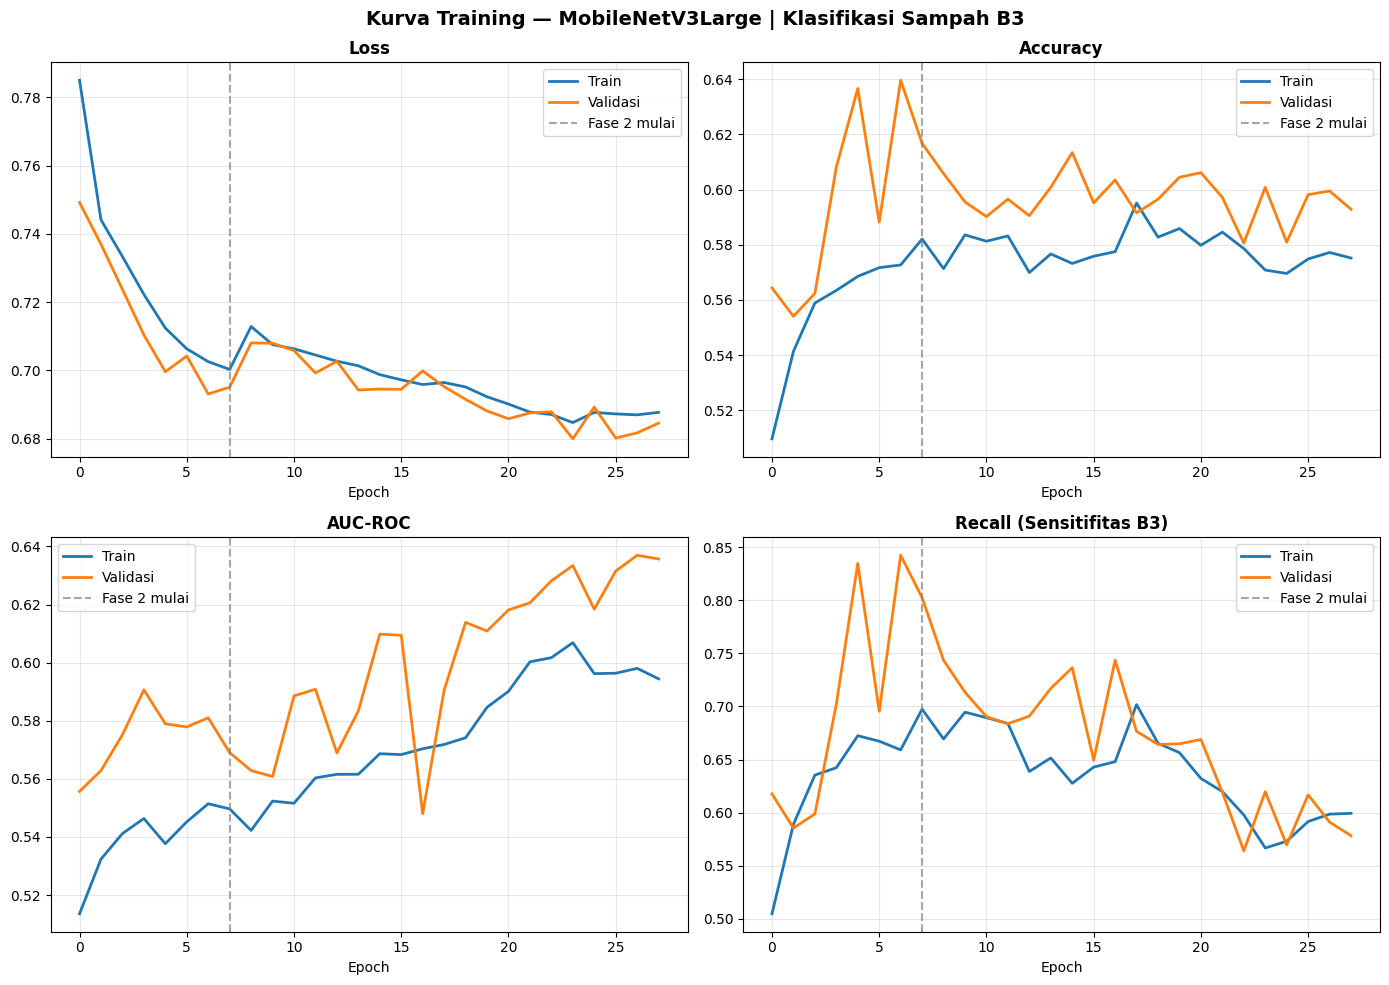

✅ Plot disimpan ke folder project


In [14]:
def merge_histories(h1, h2):
    merged = {}
    for key in h1.history:
        merged[key] = h1.history[key] + h2.history[key]
    return merged

hist = merge_histories(history1, history2)
n_phase1 = len(history1.history["loss"])

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Kurva Training — MobileNetV3Large | Klasifikasi Sampah B3",
             fontsize=14, fontweight="bold")

for ax, (train_key, val_key, title) in zip(axes.flat, [
    ("loss",      "val_loss",      "Loss"),
    ("accuracy",  "val_accuracy",  "Accuracy"),
    ("auc",       "val_auc",       "AUC-ROC"),
    ("recall",    "val_recall",    "Recall (Sensitifitas B3)"),
]):
    ax.plot(hist[train_key], label="Train", linewidth=2)
    ax.plot(hist[val_key],   label="Validasi", linewidth=2)
    ax.axvline(n_phase1 - 1, color="gray", linestyle="--", alpha=0.7, label="Fase 2 mulai")
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Epoch")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(str(PROJECT_DIR / "training_curves_v3.png"), dpi=150, bbox_inches="tight")
plt.show()
print("✅ Plot disimpan ke folder project")

## 12. 📊 Evaluasi pada Data Test

In [15]:
print("=" * 60)
print("EVALUASI MODEL PADA DATA TEST")
print("=" * 60)

test_results = model.evaluate(test_ds_proc, verbose=1)
test_metrics = dict(zip(model.metrics_names, test_results))

print("\n📊 Hasil Evaluasi Test Set:")
for name, value in test_metrics.items():
    print(f"   {name:12s} : {value:.4f}")

EVALUASI MODEL PADA DATA TEST
47/47 ━━━━━━━━━━━━━━━━━━━━ 10s 205ms/step - accuracy: 0.5847 - auc: 0.6228 - loss: 0.6866 - precision: 0.7135 - recall: 0.5754

📊 Hasil Evaluasi Test Set:
   loss         : 0.6866
   compile_metrics : 0.5847


## 13. 🔢 Confusion Matrix

47/47 ━━━━━━━━━━━━━━━━━━━━ 11s 205ms/step


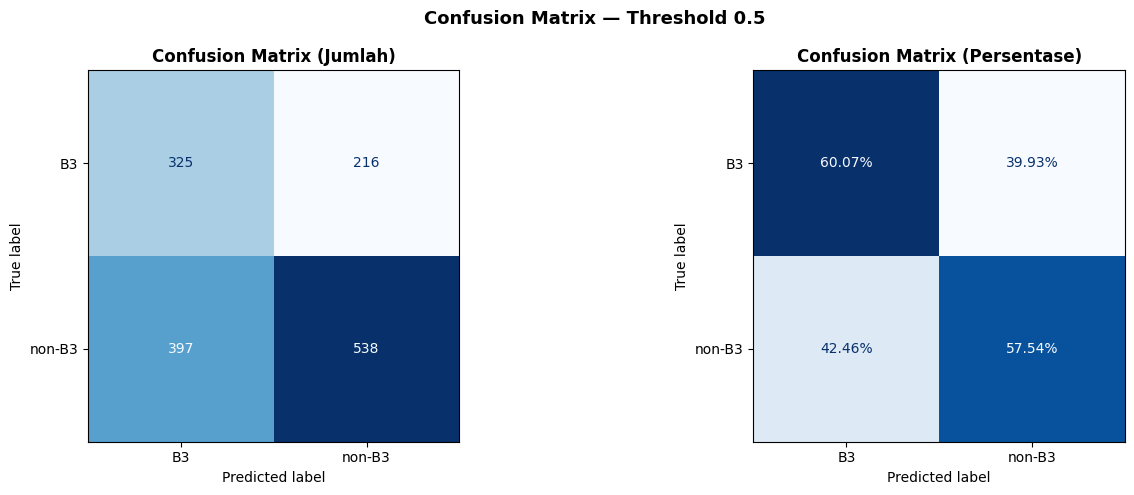

✅ Plot disimpan ke folder project


In [16]:
y_pred_proba = model.predict(test_ds_proc, verbose=1).flatten()
y_true       = np.concatenate([y.numpy() for _, y in test_ds]).flatten().astype(int)

THRESHOLD = 0.5
y_pred    = (y_pred_proba >= THRESHOLD).astype(int)

cm = confusion_matrix(y_true, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot(
    ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Confusion Matrix (Jumlah)", fontweight="bold")

cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
ConfusionMatrixDisplay(cm_norm, display_labels=CLASS_NAMES).plot(
    ax=axes[1], colorbar=False, cmap="Blues", values_format=".2%")
axes[1].set_title("Confusion Matrix (Persentase)", fontweight="bold")

plt.suptitle(f"Confusion Matrix — Threshold {THRESHOLD}", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(str(PROJECT_DIR / "confusion_matrix_v3.png"), dpi=150, bbox_inches="tight")
plt.show()
print("✅ Plot disimpan ke folder project")

## 14. 📋 Classification Report

In [17]:
print("=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4))

b3_idx    = CLASS_NAMES.index("B3")
prec_b3   = precision_score(y_true, y_pred, pos_label=b3_idx)
recall_b3 = recall_score(y_true, y_pred, pos_label=b3_idx)
f1_b3     = f1_score(y_true, y_pred, pos_label=b3_idx)

print("\n🔴 Fokus kelas B3 (kritis):")
print(f"   Precision : {prec_b3:.4f}")
print(f"   Recall    : {recall_b3:.4f}  ← sensitifitas deteksi B3")
print(f"   F1-Score  : {f1_b3:.4f}")

CLASSIFICATION REPORT
              precision    recall  f1-score   support

          B3     0.4501    0.6007    0.5146       541
      non-B3     0.7135    0.5754    0.6371       935

    accuracy                         0.5847      1476
   macro avg     0.5818    0.5881    0.5759      1476
weighted avg     0.6170    0.5847    0.5922      1476


🔴 Fokus kelas B3 (kritis):
   Precision : 0.4501
   Recall    : 0.6007  ← sensitifitas deteksi B3
   F1-Score  : 0.5146


## 15. 🎯 Threshold Optimal (F1 B3)

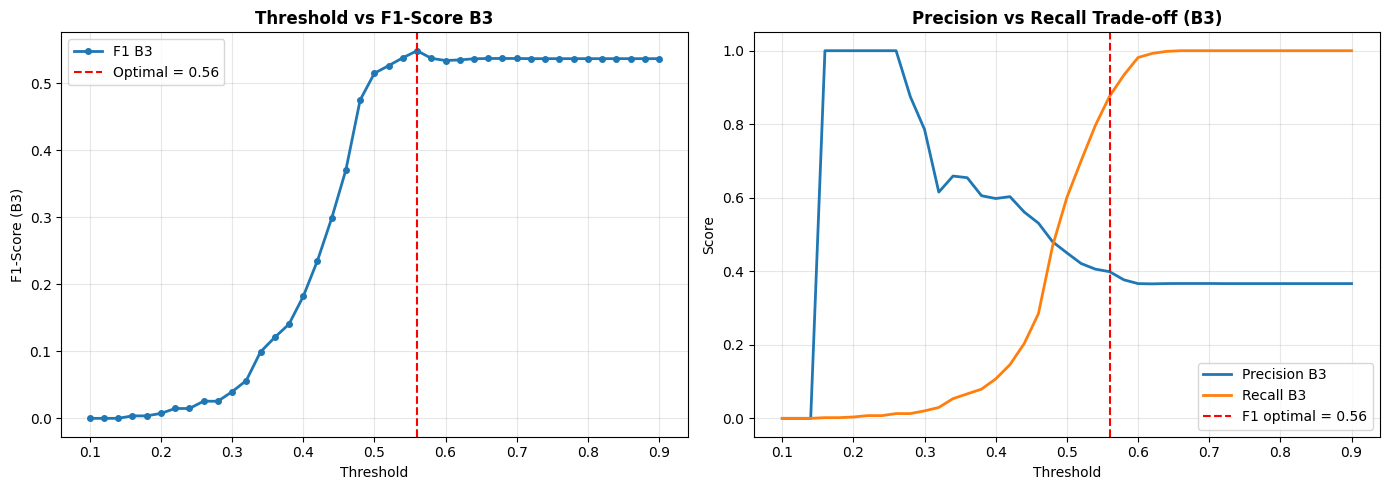


✅ Threshold optimal : 0.56 (F1 B3 = 0.5483)
   Gunakan nilai ini di aplikasi Streamlit!


In [18]:
thresholds   = np.arange(0.1, 0.91, 0.02)
f1_b3_scores = [f1_score(y_true, (y_pred_proba >= t).astype(int),
                          pos_label=0, zero_division=0) for t in thresholds]

# ✅ Juga hitung precision-recall trade-off
prec_scores   = [precision_score(y_true, (y_pred_proba >= t).astype(int),
                                  pos_label=0, zero_division=0) for t in thresholds]
recall_scores = [recall_score(y_true, (y_pred_proba >= t).astype(int),
                               pos_label=0, zero_division=0) for t in thresholds]

best_t  = thresholds[np.argmax(f1_b3_scores)]
best_f1 = max(f1_b3_scores)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(thresholds, f1_b3_scores, marker="o", markersize=4, linewidth=2, label="F1 B3")
axes[0].axvline(best_t, color="red", linestyle="--", label=f"Optimal = {best_t:.2f}")
axes[0].set_xlabel("Threshold"); axes[0].set_ylabel("F1-Score (B3)")
axes[0].set_title("Threshold vs F1-Score B3", fontweight="bold")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(thresholds, prec_scores,   linewidth=2, label="Precision B3")
axes[1].plot(thresholds, recall_scores, linewidth=2, label="Recall B3")
axes[1].axvline(best_t, color="red", linestyle="--", label=f"F1 optimal = {best_t:.2f}")
axes[1].set_xlabel("Threshold"); axes[1].set_ylabel("Score")
axes[1].set_title("Precision vs Recall Trade-off (B3)", fontweight="bold")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(str(PROJECT_DIR / "threshold_f1_v3.png"), dpi=150, bbox_inches="tight")
plt.show()

print(f"\n✅ Threshold optimal : {best_t:.2f} (F1 B3 = {best_f1:.4f})")
print(f"   Gunakan nilai ini di aplikasi Streamlit!")

## 16. 💾 Simpan Model

In [19]:
# Simpan H5 (kompatibilitas dengan Streamlit lama)
model.save(str(MODEL_PATH))
print(f"✅ Model H5 disimpan → {MODEL_PATH}")

# Simpan format .keras (native Keras 3.x)
keras_path = PROJECT_DIR / "model_b3_v3.keras"
model.save(str(keras_path))
print(f"✅ Model .keras disimpan → {keras_path}")

# Simpan SavedModel (untuk TFLite / TFServing)
saved_model_path = PROJECT_DIR / "model_b3_v3_savedmodel"
model.export(str(saved_model_path))
print(f"✅ SavedModel disimpan → {saved_model_path}/")

h5_size = os.path.getsize(str(MODEL_PATH)) / 1e6
print(f"\nUkuran model H5 : {h5_size:.2f} MB")

print("\n📁 Semua file tersimpan di folder project:")
for fname in ["model_b3_v3.h5", "model_b3_v3.keras", "checkpoint_best_v3.h5"]:
    path = PROJECT_DIR / fname
    exists = "✅" if path.exists() else "❌"
    print(f"   {exists} {fname}")

✅ Model H5 disimpan → model_b3_v3.h5
✅ Model .keras disimpan → model_b3_v3.keras
INFO:tensorflow:Assets written to: model_b3_v3_savedmodel\assets


INFO:tensorflow:Assets written to: model_b3_v3_savedmodel\assets


Saved artifact at 'model_b3_v3_savedmodel'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_image')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  2328644617232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2328644619344: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2328644619536: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2328644618000: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2328644618576: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2328644618192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2328644620496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2328644620304: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2328644619152: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2328644621072: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2328644619728: TensorSpec(sha

## 17. 🔄 Cara Pakai Model di Streamlit

> ⚠️ Karena ganti ke MobileNetV3, **preprocessing di Streamlit juga harus diupdate**.

In [20]:
# ============================================================
# Contoh kode untuk Streamlit app (salin ke app.py Anda)
# ============================================================
streamlit_snippet = '''
import tensorflow as tf
import numpy as np
from tensorflow.keras.applications.mobilenet_v3 import preprocess_input  # ← PENTING: V3!
from PIL import Image

# Load model
@st.cache_resource
def load_model():
    return tf.keras.models.load_model("model_b3_v3.h5")

model = load_model()
THRESHOLD = {best_t:.2f}  # threshold optimal dari training

def predict(image: Image.Image):
    img = image.resize((224, 224))
    arr = np.array(img, dtype="float32")
    arr = np.expand_dims(arr, axis=0)        # (1, 224, 224, 3)
    arr = preprocess_input(arr)              # ← mobilenet_v3 preprocess
    prob = model.predict(arr)[0][0]
    label = "B3" if prob < THRESHOLD else "non-B3"  # sesuaikan urutan class
    return label, float(prob)
'''.format(best_t=best_t)

print(streamlit_snippet)


import tensorflow as tf
import numpy as np
from tensorflow.keras.applications.mobilenet_v3 import preprocess_input  # ← PENTING: V3!
from PIL import Image

# Load model
@st.cache_resource
def load_model():
    return tf.keras.models.load_model("model_b3_v3.h5")

model = load_model()
THRESHOLD = 0.56  # threshold optimal dari training

def predict(image: Image.Image):
    img = image.resize((224, 224))
    arr = np.array(img, dtype="float32")
    arr = np.expand_dims(arr, axis=0)        # (1, 224, 224, 3)
    arr = preprocess_input(arr)              # ← mobilenet_v3 preprocess
    prob = model.predict(arr)[0][0]
    label = "B3" if prob < THRESHOLD else "non-B3"  # sesuaikan urutan class
    return label, float(prob)



## 18. ✅ Ringkasan Hasil

In [21]:
print("=" * 60)
print("  RINGKASAN HASIL TRAINING & EVALUASI")
print("=" * 60)
print(f"  Model         : MobileNetV3Large (Transfer Learning)")
print(f"  Input size    : {IMG_SIZE[0]}×{IMG_SIZE[1]} px")
print(f"  Preprocessing : mobilenet_v3.preprocess_input")
print(f"  Epochs fase 1 : {len(history1.history['loss'])}")
print(f"  Epochs fase 2 : {len(history2.history['loss'])}")
print()
print("  📊 Metrik TEST SET:")
for name, value in test_metrics.items():
    print(f"     {name:12s}: {value:.4f}")
print()
print(f"  🔴 Kelas B3:")
print(f"     Precision : {prec_b3:.4f}")
print(f"     Recall    : {recall_b3:.4f}")
print(f"     F1-Score  : {f1_b3:.4f}")
print()
print(f"  🌐 Threshold untuk Streamlit: {best_t:.2f}")
print(f"  💾 Model tersimpan           : model_b3_v3.h5")
print("=" * 60)

  RINGKASAN HASIL TRAINING & EVALUASI
  Model         : MobileNetV3Large (Transfer Learning)
  Input size    : 224×224 px
  Preprocessing : mobilenet_v3.preprocess_input
  Epochs fase 1 : 8
  Epochs fase 2 : 20

  📊 Metrik TEST SET:
     loss        : 0.6866
     compile_metrics: 0.5847

  🔴 Kelas B3:
     Precision : 0.4501
     Recall    : 0.6007
     F1-Score  : 0.5146

  🌐 Threshold untuk Streamlit: 0.56
  💾 Model tersimpan           : model_b3_v3.h5
